Praktikum  Data Preprocessing 

Missing Value

In [1]:
import pandas as pd
path = "dataMissingValue.csv"
df = pd.read_csv(path)
df

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
1,B,High School,NaN,17.0,banana,41.0
2,C,High School,NaN,NaN,watermelon,NaN
3,D,High School,NaN,16.0,NaN,38.0
4,E,Middle School,B,15.0,banana,37.0
5,F,Middle School,NaN,14.0,grapes,NaN
6,G,Middle School,O,NaN,mango,36.0
7,H,High School,A,16.0,papaya,39.0
8,I,High School,NaN,18.0,NaN,40.0
9,J,Middle School,NaN,NaN,avocado,35.0


Menghitung jumlah data yang hilang (NaN) di setiap kolom untuk memahami kualitas dataset.

In [2]:
df.isnull().sum()

Name            0
School Level    0
Blood Type      6
Age             3
Fav Fruit       2
Shoe Chart      2
dtype: int64

Menghitung persentase data yang hilang untuk mengevaluasi apakah perlu dihapus atau diisi ulang.

In [3]:
percent_missing = 100 * df.isnull().mean()
percent_missing

Name             0.0
School Level     0.0
Blood Type      60.0
Age             30.0
Fav Fruit       20.0
Shoe Chart      20.0
dtype: float64

df.dropna digunakan untuk menghapus baris atau kolom yang memiliki missing values.

In [4]:
df.dropna(axis=0)

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
4,E,Middle School,B,15.0,banana,37.0
7,H,High School,A,16.0,papaya,39.0


In [5]:
df.dropna(axis=1)

,Name,School Level
0,A,High School
1,B,High School
2,C,High School
3,D,High School
4,E,Middle School
5,F,Middle School
6,G,Middle School
7,H,High School
8,I,High School
9,J,Middle School


thresh = 5 berarti hanya baris yang memiliki minimal 5 nilai valid yang dipertahankan. Contohnya baris indeks 2 hilang karena pada indeks tersebut nilai yang tidak berisi NaN kurang dari 5.

In [6]:
df.dropna(thresh=5)

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
1,B,High School,NaN,17.0,banana,41.0
4,E,Middle School,B,15.0,banana,37.0
6,G,Middle School,O,NaN,mango,36.0
7,H,High School,A,16.0,papaya,39.0


Dengan menambahkan subset 'Age', maka hanya baris yang berisi NaN di kolom Age yang dihapus.

In [7]:
df.dropna(subset=['Age'])

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
1,B,High School,NaN,17.0,banana,41.0
3,D,High School,NaN,16.0,NaN,38.0
4,E,Middle School,B,15.0,banana,37.0
5,F,Middle School,NaN,14.0,grapes,NaN
7,H,High School,A,16.0,papaya,39.0
8,I,High School,NaN,18.0,NaN,40.0


Menghapus kolom Blood Type dengan df.drop()

In [8]:
df_drop = df.drop(columns='Blood Type')
df_drop

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.0,apple,36.0
1,B,High School,17.0,banana,41.0
2,C,High School,NaN,watermelon,NaN
3,D,High School,16.0,NaN,38.0
4,E,Middle School,15.0,banana,37.0
5,F,Middle School,14.0,grapes,NaN
6,G,Middle School,NaN,mango,36.0
7,H,High School,16.0,papaya,39.0
8,I,High School,18.0,NaN,40.0
9,J,Middle School,NaN,avocado,35.0


.fillna() digunakan untuk mengisi nilai yang kosong (missing values). Imputasi nilai bisa menggunakan beberapa metode statistik seperti mean, median, mode. Missing value pada kolom Age akan diisi dengan nilai rata-rata atau mean, Shoe Chart dengan median, dan Fav Fruit dengan mode.

In [9]:
df_filled = df_drop.copy()
df_filled['Age'] = df['Age'].fillna(df['Age'].mean())
df_filled

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.000000,apple,36.0
1,B,High School,17.000000,banana,41.0
2,C,High School,15.857143,watermelon,NaN
3,D,High School,16.000000,NaN,38.0
4,E,Middle School,15.000000,banana,37.0
5,F,Middle School,14.000000,grapes,NaN
6,G,Middle School,15.857143,mango,36.0
7,H,High School,16.000000,papaya,39.0
8,I,High School,18.000000,NaN,40.0
9,J,Middle School,15.857143,avocado,35.0


In [10]:
df_filled['Shoe Chart'] = df['Shoe Chart'].fillna(df['Shoe Chart'].median())
df_filled

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.000000,apple,36.0
1,B,High School,17.000000,banana,41.0
2,C,High School,15.857143,watermelon,37.5
3,D,High School,16.000000,NaN,38.0
4,E,Middle School,15.000000,banana,37.0
5,F,Middle School,14.000000,grapes,37.5
6,G,Middle School,15.857143,mango,36.0
7,H,High School,16.000000,papaya,39.0
8,I,High School,18.000000,NaN,40.0
9,J,Middle School,15.857143,avocado,35.0


In [11]:
df_filled['Fav Fruit'] = df['Fav Fruit'].fillna(df['Fav Fruit'].mode().iloc[0])
df_filled

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.000000,apple,36.0
1,B,High School,17.000000,banana,41.0
2,C,High School,15.857143,watermelon,37.5
3,D,High School,16.000000,banana,38.0
4,E,Middle School,15.000000,banana,37.0
5,F,Middle School,14.000000,grapes,37.5
6,G,Middle School,15.857143,mango,36.0
7,H,High School,16.000000,papaya,39.0
8,I,High School,18.000000,banana,40.0
9,J,Middle School,15.857143,avocado,35.0


Selain itu, missing value bisa juga diisi dengan back fill dan forward fill. Back fill untuk mengisi nilai kosong di "Shoe Chart" dengan nilai dari bawahnya atau setelahnya. Forward fill ntuk mengisi nilai kosong di "Fav Fruit" dengan nilai sebelumnya.

In [12]:
df_filled2 = df_drop.copy()
df_filled2['Shoe Chart'] = df_filled2['Shoe Chart'].replace("", None).bfill()
df_filled2

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.0,apple,36.0
1,B,High School,17.0,banana,41.0
2,C,High School,NaN,watermelon,38.0
3,D,High School,16.0,NaN,38.0
4,E,Middle School,15.0,banana,37.0
5,F,Middle School,14.0,grapes,36.0
6,G,Middle School,NaN,mango,36.0
7,H,High School,16.0,papaya,39.0
8,I,High School,18.0,NaN,40.0
9,J,Middle School,NaN,avocado,35.0


In [13]:
df_filled2['Fav Fruit'] = df_filled2['Fav Fruit'].replace("", None).ffill()
df_filled2

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.0,apple,36.0
1,B,High School,17.0,banana,41.0
2,C,High School,NaN,watermelon,38.0
3,D,High School,16.0,watermelon,38.0
4,E,Middle School,15.0,banana,37.0
5,F,Middle School,14.0,grapes,36.0
6,G,Middle School,NaN,mango,36.0
7,H,High School,16.0,papaya,39.0
8,I,High School,18.0,papaya,40.0
9,J,Middle School,NaN,avocado,35.0


Outliers

In [14]:
path = "weight-height_outlier.csv"
df2 = pd.read_csv(path)
df2

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


Mendeteksi outliers secara visual dengan menggunakan boxplot dari seaborn dan menghapus outliers dengan menggunakan Interquartile Range. Outliers berada di luar titik whiskers pada boxplot.

<Axes: ylabel='Height'>

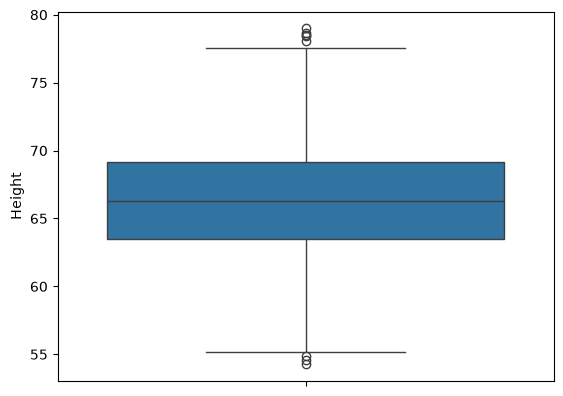

In [15]:
import seaborn as sns
sns.boxplot(df2['Height'])

<Axes: ylabel='Height'>

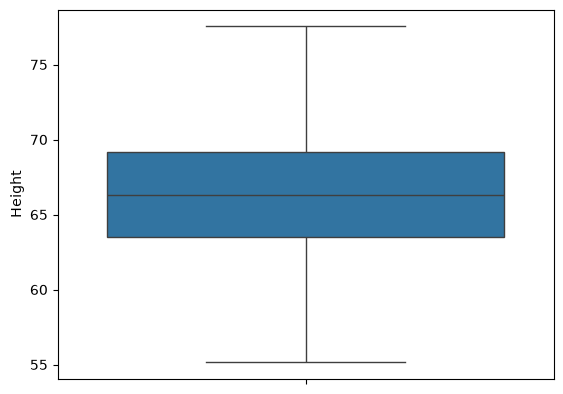

In [16]:
import numpy as np

q1, q3 = np.percentile(df2['Height'], [25, 75])
iqr = q3 - q1
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)

clean_data = df2[(df2['Height'] >= lower_bound) & (df2['Height'] <= upper_bound)]
sns.boxplot(clean_data['Height'])

<Axes: ylabel='Weight'>

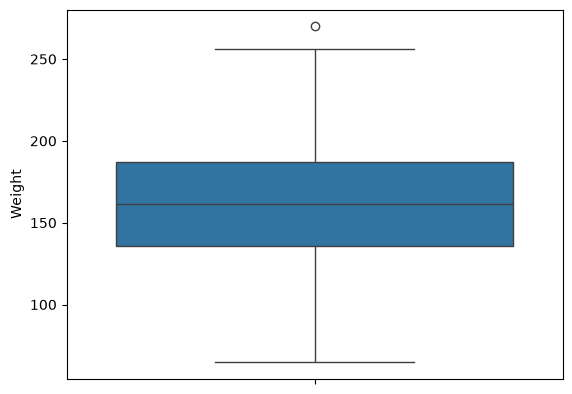

In [17]:
sns.boxplot(df2['Weight'])

<Axes: ylabel='Weight'>

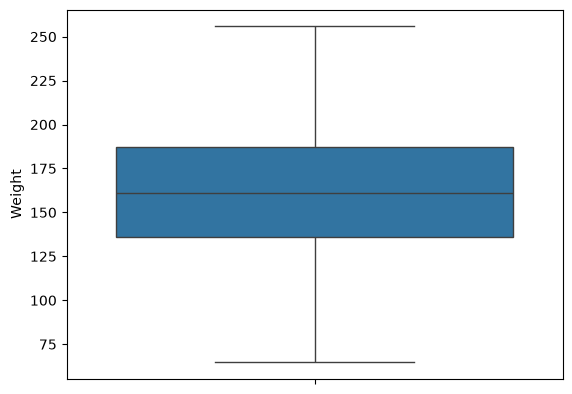

In [18]:
q1, q3 = np.percentile(df2['Weight'], [25, 75])
iqr = q3 - q1
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)

clean_data = df2[(df2['Weight'] >= lower_bound) & (df2['Weight'] <= upper_bound)]
sns.boxplot(clean_data['Weight'])

Mendeteksi outliers dengan visualisasi dari matplotlib.

C:\Users\USER\AppData\Local\Temp\ipykernel_42564\1575731421.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(df2[col], vert=False)
C:\Users\USER\AppData\Local\Temp\ipykernel_42564\1575731421.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(df2[col], vert=False)


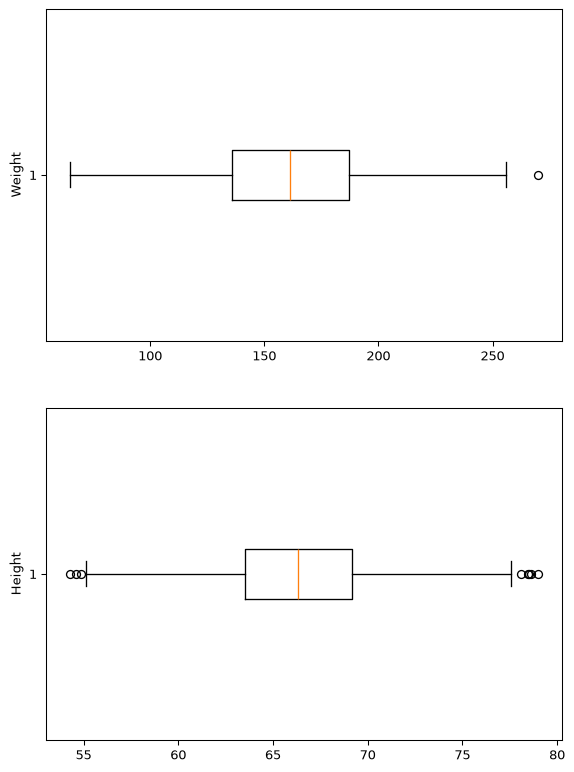

In [19]:
import matplotlib.pyplot as plt

columns_to_plot = ['Weight', 'Height']
columns_to_plot = [col for col in columns_to_plot if col in df2.columns]

fig, axs = plt.subplots(len(columns_to_plot), 1, dpi=95, figsize=(7, 5 * len(columns_to_plot)))
if len(columns_to_plot) == 1:
    axs = [axs]

for i, col in enumerate(columns_to_plot):
    axs[i].boxplot(df2[col], vert=False)
    axs[i].set_ylabel(col)

plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_42564\3032376745.py:19: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(clean_data[col], vert=False)
C:\Users\USER\AppData\Local\Temp\ipykernel_42564\3032376745.py:19: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(clean_data[col], vert=False)


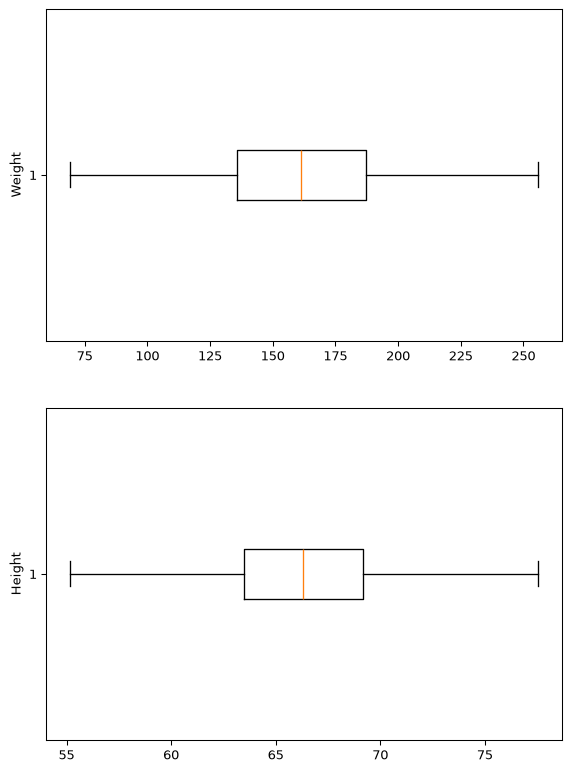

In [20]:
def remove_outliers_sequentially(df2, columns):
    df_cleaned = df2.copy()
    for col in columns:
        q1, q3 = np.percentile(df_cleaned[col], [25, 75])
        iqr = q3 - q1
        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 * iqr)
        df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]
    return df_cleaned

clean_data = remove_outliers_sequentially(df2, ['Height', 'Weight'])

columns_to_plot = ['Weight', 'Height']
fig, axs = plt.subplots(len(columns_to_plot), 1, dpi=95, figsize=(7, 5 * len(columns_to_plot)))
if len(columns_to_plot) == 1:
    axs = [axs]

for i, col in enumerate(columns_to_plot):
    axs[i].boxplot(clean_data[col], vert=False)
    axs[i].set_ylabel(col)

plt.show()

In [21]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

numeric_cols = clean_data.select_dtypes(include=[np.number]).columns
non_numeric_cols = clean_data.select_dtypes(exclude=[np.number]).columns

rescaled_numeric = scaler.fit_transform(clean_data[numeric_cols])
rescaled_numeric

array([[0.83480376, 0.92524773],
       [0.6086688 , 0.49939825],
       [0.84654949, 0.76925146],
       ...,
       [0.38928431, 0.31834619],
       [0.61993463, 0.50764944],
       [0.30339752, 0.23901104]], shape=(9992, 2))

In [22]:
rescaled_df = pd.DataFrame(rescaled_numeric, columns=numeric_cols, index=clean_data.index)
final_df = pd.concat([clean_data[non_numeric_cols], rescaled_df], axis=1)
final_df

,Gender,Height,Weight
0,Male,0.834804,0.925248
1,Male,0.608669,0.499398
2,Male,0.846549,0.769251
3,Male,0.740332,0.808322
4,Male,0.657774,0.735053
...,...,...,...
9995,Female,0.492177,0.362771
9996,Female,0.532113,0.545189
9997,Female,0.389284,0.318346
9998,Female,0.619935,0.507649


Tugas 1. Ikuti semua step dalam modul ini 2. Handling missing value dari dataset 'Titanic-Dataset.csv' Tampilkan df.isnull().sum() ketika semua missing value sudah diatasi 3. Handling outliers dari dataset 'diabetes.csv' Pilih 3 kolom untuk deteksi Bebas menggunakan matplotlib atau seaborn

Tugas Praktikum Data Preprocessing 

Tugas 2 — Handling Missing Value (Titanic-Dataset.csv)

In [3]:
import pandas as pd

df_titanic = pd.read_csv('Titanic-Dataset.csv')

Analisis:
Pada langkah pertama, kita mengimpor library pandas dan membaca file Titanic-Dataset.csv menggunakan pd.read_csv() untuk memuat dataset ke dalam bentuk DataFrame.

In [5]:
df_titanic['Age'] = df_titanic['Age'].fillna(df_titanic['Age'].median())

Analisis:
Kolom Age memiliki 177 missing value (sekitar 19,87% dari total data). Karena Age bertipe numerik, kita mengisi nilai kosong tersebut dengan nilai median (28,0 tahun) menggunakan fungsi .fillna(). Penggunaan median dipilih agar estimasi data tidak terpengaruh oleh pencilan (outlier).

In [6]:
df_titanic['Embarked'] = df_titanic['Embarked'].fillna(df_titanic['Embarked'].mode()[0])

Analisis:
Kolom Embarked memiliki 2 missing value (0,22%). Karena Embarked merupakan data kualitatif/kategorikal (lokasi pelabuhan keberangkatan), kita melakukan imputasi menggunakan modus (kategori yang paling sering muncul) yaitu 'S' (Southampton).

In [7]:
df_titanic = df_titanic.drop(columns=['Cabin'])

Analisis:
Kolom Cabin memiliki 687 missing value dari total 891 baris data (sekitar 77,1% data hilang). Mengisi nilai kosong dengan proporsi data hilang di atas 75% akan menimbulkan bias berlebih pada dataset, sehingga keputusan terbaik adalah mengeliminasi (drop) kolom tersebut menggunakan df.drop(), persis seperti penghapusan kolom Blood Type pada modul.

In [8]:
df_titanic.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Analisis:
Langkah terakhir adalah mengeksekusi df_titanic.isnull().sum() untuk memverifikasi bahwa seluruh missing value pada setiap kolom di DataFrame telah bernilai 0.

Tugas 3 — Handling Outliers (diabetes.csv)

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df_diabetes = pd.read_csv('diabetes.csv')
cols = ['BMI', 'Insulin', 'BloodPressure']

Analisis:
Kita memuat dataset diabetes.csv dan menentukan 3 kolom numerik yang akan dianalisis pencilannya, yaitu BMI, Insulin, dan BloodPressure.

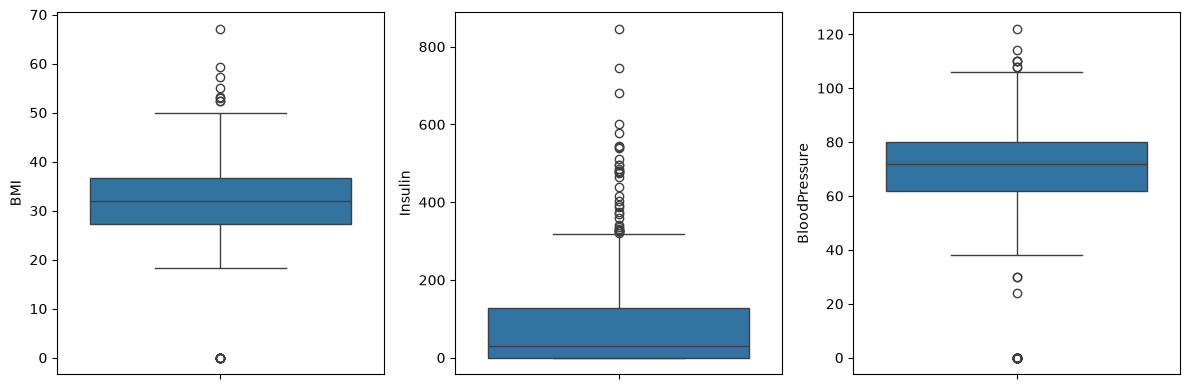

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
for i, col in enumerate(cols):
    sns.boxplot(y=df_diabetes[col], ax=axs[i])
plt.tight_layout()
plt.show()

Analisis:
Langkah awal penanganan outlier adalah deteksi secara visual menggunakan diagram boxplot dari seaborn.  Pada kolom BloodPressure, terlihat nilai 0 (tidak valid secara medis) dan pencilan di atas 107 mmHg.Pada kolom BMI, terdapat data bernilai 0 dan pencilan di atas 50.Pada kolom Insulin, terdapat sebaran pencilan atas (upper outliers) yang cukup banyak hingga melebihi nilai 300.

In [11]:
def remove_outliers(df_input, columns):
    df_clean = df_input.copy()
    for col in columns:
        q1, q3 = np.percentile(df_clean[col], [25, 75])
        iqr = q3 - q1
        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 * iqr)
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    return df_clean

clean_diabetes = remove_outliers(df_diabetes, cols)

Analisis:
Fungsi remove_outliers menghitung Interquartile Range ($\text{IQR} = Q3 - Q1$) untuk menentukan batas bawah ($\text{lower\_bound} = Q1 - 1,5 \times \text{IQR}$) dan batas atas ($\text{upper\_bound} = Q3 + 1,5 \times \text{IQR}$). Data yang berada di luar batas interval tersebut dianggap sebagai outlier dan difilter/dihapus secara sekuensial. 

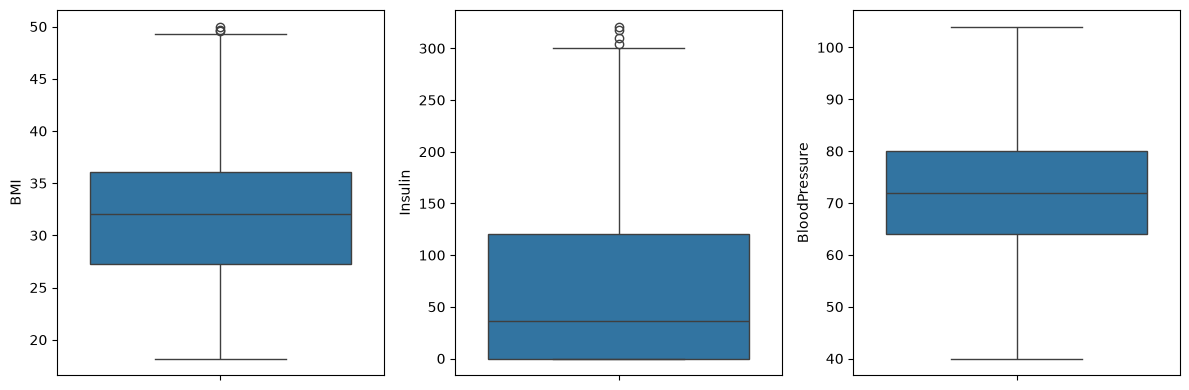

Jumlah data sebelum: 768
Jumlah data setelah: 678


In [12]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
for i, col in enumerate(cols):
    sns.boxplot(y=clean_diabetes[col], ax=axs[i])
plt.tight_layout()
plt.show()

print(f"Jumlah data sebelum: {len(df_diabetes)}")
print(f"Jumlah data setelah: {len(clean_diabetes)}")

Analisis:
Setelah fungsi dijalankan, kita menampilkan kembali boxplot untuk memastikan bahwa titik-titik pencilan di luar garis whisker sudah jauh berkurang/bersih. Dari hasil cetak jumlah baris, dataset berkurang dari 768 baris menjadi 678 baris (90 baris pencilan dihapus). Pembersihan ini penting agar data bernilai abnormal (seperti nilai 0 pada tekanan darah/BMI) tidak mengganggu performa dan akurasi model machine learning selanjutnya.